# Matcher With Autodiff

This notebook is the follow-up to `matcher_basics.ipynb`.

The first notebook used `MatchProblem` directly. Here we solve the same kind of small optics problems through the new autodiff-oriented linear API:

- `elem.linear_r(...)`
- `elem.linear_r_full(...)`
- `trace_linear_twiss(...)`
- `jax.value_and_grad(...)`

The point is not to replace `Matcher` immediately. The point is to show that the same optics tasks can already be written as pure differentiable objectives.


## Setup

This notebook uses JAX for derivatives and SciPy for the optimizer loop. The actual optics calculations still come from Ocelot's shared linear formulas.

The examples below use `jax.value_and_grad(...)` but intentionally do **not** `jit` the full objective yet. Some current wrapper paths still contain Python control flow such as `if self.l == 0`, which is fine for autodiff but not yet fully JIT-safe.


In [1]:
from pathlib import Path
import sys
import warnings

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'ocelot').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

warnings.filterwarnings(
    'ignore',
    message='Cavity does not declare support for TransferMap; global lattice request falls back to default CavityTM.'
)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

from ocelot import MagneticLattice
from ocelot.cpbd.elements import Cavity, Drift, Marker, Quadrupole
from ocelot.cpbd.twiss_linear import make_twiss_state, trace_linear_twiss


initializing ocelot...


In [2]:
def twiss_seed_state(E=1.0, xp=jnp):
    return make_twiss_state(
        beta_x=10.0,
        beta_y=10.0,
        alpha_x=0.0,
        alpha_y=0.0,
        E=E,
        xp=xp,
    )


def solve_with_jax(objective, x0, bounds, max_iter=200):
    x0 = np.atleast_1d(np.asarray(x0, dtype=float))
    value_and_grad = jax.value_and_grad(objective)

    def scipy_value_and_grad(x):
        value, grad = value_and_grad(jnp.asarray(x))
        return float(value), np.asarray(grad, dtype=float)

    result = minimize(
        lambda x: scipy_value_and_grad(x)[0],
        x0=x0,
        jac=lambda x: scipy_value_and_grad(x)[1],
        bounds=bounds,
        method='L-BFGS-B',
        options={'maxiter': max_iter},
    )
    return result


def state_summary(state, keys=('s', 'E', 'beta_x', 'alpha_x', 'beta_y', 'alpha_y')):
    return {key: float(state[key]) for key in keys if key in state}


def beta_trace(states):
    s = np.array([float(state['s']) for state in states])
    beta_x = np.array([float(state['beta_x']) for state in states])
    beta_y = np.array([float(state['beta_y']) for state in states])
    return s, beta_x, beta_y


## 1. Match a Drift Length With a Differentiable Twiss Target

This is the autodiff version of the first matcher example. The target is still the same: force the end marker to land at `s = 2.2 m`.

This example is intentionally simple and it works well because the objective depends on the path length `s`, not on a delicate matrix derivative.


In [3]:
start = Marker(eid='START')
dvar = Drift(l=0.7, eid='DVAR')
end = Marker(eid='END')
lat = MagneticLattice((start, dvar, end))
tws0 = twiss_seed_state()


def objective_drift_length(x):
    l = x[0]
    states = trace_linear_twiss(lat, tws0, xp=jnp, overrides={dvar: {'l': l}})
    return (states[-1]['s'] - 2.2) ** 2

result = solve_with_jax(objective_drift_length, x0=[0.7], bounds=[(0.0, None)], max_iter=80)
states = trace_linear_twiss(lat, tws0, xp=jnp, overrides={dvar: {'l': result.x[0]}})
print('success =', result.success)
print('optimized drift length =', result.x[0])
print('final state =', state_summary(states[-1], keys=('s',)))


success = True
optimized drift length = 2.2
final state = {'s': 2.2}


## 2. Match the End Energy by Varying Cavity Voltage

This mirrors the cavity example from `matcher_basics.ipynb`, but the objective is now written explicitly as a differentiable scalar function.


In [4]:
start = Marker(eid='START')
cav = Cavity(l=0.5, v=0.02, phi=0.0, freq=1.3e9, eid='CAV')
end = Marker(eid='END')
lat = MagneticLattice((start, cav, end))
tws0 = twiss_seed_state(E=1.0)


def objective_cavity_voltage(x):
    v = x[0]
    states = trace_linear_twiss(lat, tws0, xp=jnp, overrides={cav: {'v': v}})
    return (states[-1]['E'] - 1.03) ** 2

result = solve_with_jax(objective_cavity_voltage, x0=[0.02], bounds=[(0.0, 0.05)], max_iter=120)
states = trace_linear_twiss(lat, tws0, xp=jnp, overrides={cav: {'v': result.x[0]}})
print('success =', result.success)
print('optimized cavity voltage =', result.x[0])
print('final state =', state_summary(states[-1], keys=('E',)))


success = True
optimized cavity voltage = 0.03000000000000008
final state = {'E': 1.03}


## 3. One Example That Does Not Yet Work Cleanly: Direct Drift `R12` Target

Conceptually this should be the easiest case of all, because for a pure drift `R12 = L`.

But right now the exact autodiff path for this case is not clean: the JAX gradient through the current drift matrix implementation returns `NaN` at the exact drift corner (`k1 = 0`, `hx = 0`).

This is not a limitation of the idea. It is a limitation of the current low-level implementation around the `k -> 0` branch in the backend-generic magnet matrix helper.


In [5]:
dvar = Drift(l=1.1, eid='DVAR')


def objective_r12_drift(x):
    l = x[0]
    R = dvar.linear_r_full(l=l, energy=1.0, xp=jnp)
    return (R[0, 1] - 2.7) ** 2

value, grad = jax.value_and_grad(objective_r12_drift)(jnp.array([1.1]))
print('objective value =', float(value))
print('gradient =', np.asarray(grad))


objective value = 2.5600000000000005
gradient = [nan]


The practical consequence is:

- the same `R12` target works fine in `Matcher`
- the same target is not yet a good autodiff demo when it passes exactly through the drift corner
- fixing this would require making the `k -> 0` limit in `linear_magnet_matrix(...)` differentiable in the JAX path, not adding a new high-level API


## 4. One Knob Driving Two Quadrupoles

This is the autodiff version of the linked power-supply example. Instead of `vary_linked_elements(...)`, we define one scalar parameter `ps` and map it explicitly to `q1.k1 = ps`, `q2.k1 = -ps`.


In [6]:
start = Marker(eid='S')
q1 = Quadrupole(l=0.2, k1=0.7, eid='Q1')
mid = Drift(l=0.5, eid='D1')
q2 = Quadrupole(l=0.2, k1=-0.7, eid='Q2')
end = Marker(eid='E')
lat = MagneticLattice((start, q1, mid, q2, end))
tws0 = twiss_seed_state()


def objective_linked_quads(x):
    ps = x[0]
    states = trace_linear_twiss(
        lat,
        tws0,
        xp=jnp,
        overrides={
            q1: {'k1': ps},
            q2: {'k1': -ps},
        },
    )
    return (states[-1]['beta_x'] - 8.0) ** 2

result = solve_with_jax(objective_linked_quads, x0=[0.7], bounds=[(-5.0, 5.0)], max_iter=200)
states = trace_linear_twiss(
    lat,
    tws0,
    xp=jnp,
    overrides={
        q1: {'k1': result.x[0]},
        q2: {'k1': -result.x[0]},
    },
)
print('success =', result.success)
print('power-supply knob =', result.x[0])
print('q1.k1 =', result.x[0])
print('q2.k1 =', -result.x[0])
print('final state =', state_summary(states[-1], keys=('beta_x',)))


success = True
power-supply knob = 0.7795848563642923
q1.k1 = 0.7795848563642923
q2.k1 = -0.7795848563642923
final state = {'beta_x': 8.000000000093214}


## 5. Custom Objective: Minimize the Final `s`

This is the autodiff analogue of the simple `minimize_function(...)` example. The objective is written directly as a scalar function of the lattice parameter.


In [7]:
start = Marker(eid='START')
dvar = Drift(l=1.3, eid='DVAR')
end = Marker(eid='END')
lat = MagneticLattice((start, dvar, end))
tws0 = twiss_seed_state()


def objective_minimize_s(x):
    l = x[0]
    states = trace_linear_twiss(lat, tws0, xp=jnp, overrides={dvar: {'l': l}})
    return states[-1]['s']

result = solve_with_jax(objective_minimize_s, x0=[1.3], bounds=[(0.0, 5.0)], max_iter=80)
states = trace_linear_twiss(lat, tws0, xp=jnp, overrides={dvar: {'l': result.x[0]}})
print('success =', result.success)
print('optimized drift length =', result.x[0])
print('final state =', state_summary(states[-1], keys=('s',)))


success = True
optimized drift length = 0.0
final state = {'s': 0.0}


## 6. A Larger Multi-Quadrupole Example

The small examples above are useful, but they do not show why gradients become interesting.

This example is still conceptually simple:

- one beamline
- four quadrupoles
- several end-Twiss targets
- one scalar merit function

The trick is that we generate the target optics from one hidden quadrupole setting and then ask autodiff to recover *a* matching solution from a different starting point.

Important note: the recovered quadrupole strengths do **not** need to equal the hidden ones exactly. Optics matching is generally not unique. Matching the target Twiss values is what matters.


In [8]:
start = Marker(eid='START')
quads = [Quadrupole(l=0.25, k1=0.0, eid=f'Q{i+1}') for i in range(4)]
end = Marker(eid='END')
lat = MagneticLattice((
    start,
    Drift(l=0.5, eid='D1'), quads[0],
    Drift(l=0.4, eid='D2'), quads[1],
    Drift(l=0.6, eid='D3'), quads[2],
    Drift(l=0.35, eid='D4'), quads[3],
    Drift(l=0.5, eid='D5'), end,
))

tws0 = make_twiss_state(beta_x=9.0, alpha_x=0.7, beta_y=11.0, alpha_y=-0.5, E=1.0, xp=jnp)
true_k = jnp.array([0.7, -0.9, 0.5, -0.6], dtype=jnp.float64)


def trace_multi_quad(kvec):
    overrides = {q: {'k1': k} for q, k in zip(quads, kvec)}
    return trace_linear_twiss(lat, tws0, xp=jnp, overrides=overrides)


target_state = trace_multi_quad(true_k)[-1]


def objective_multi_quad(kvec):
    states = trace_multi_quad(kvec)
    end_state = states[-1]

    merit = (
        (end_state['beta_x'] - target_state['beta_x']) ** 2
        + 5.0 * (end_state['alpha_x'] - target_state['alpha_x']) ** 2
        + (end_state['beta_y'] - target_state['beta_y']) ** 2
        + 5.0 * (end_state['alpha_y'] - target_state['alpha_y']) ** 2
    )

    merit = merit + 1e-3 * jnp.sum((kvec / 2.0) ** 2)
    for state in states[1:]:
        merit = merit + 1e-4 * ((state['beta_x'] / 20.0) ** 2 + (state['beta_y'] / 20.0) ** 2)
    return merit

x0 = np.array([0.1, -0.1, 0.1, -0.1], dtype=float)
result = solve_with_jax(objective_multi_quad, x0=x0, bounds=[(-2.5, 2.5)] * 4, max_iter=200)

states_before = trace_multi_quad(jnp.asarray(x0))
states_after = trace_multi_quad(jnp.asarray(result.x))

print('success =', result.success)
print('optimized quadrupoles =', result.x)
print('target end state =', state_summary(target_state, keys=('beta_x', 'alpha_x', 'beta_y', 'alpha_y')))
print('initial end state =', state_summary(states_before[-1], keys=('beta_x', 'alpha_x', 'beta_y', 'alpha_y')))
print('final end state =', state_summary(states_after[-1], keys=('beta_x', 'alpha_x', 'beta_y', 'alpha_y')))
print('final merit =', result.fun)


success = True
optimized quadrupoles = [ 0.53806305 -0.14755483 -0.75237388  0.07629654]
target end state = {'beta_x': 4.759381840565031, 'alpha_x': -0.19880333994109545, 'beta_y': 15.823326591090431, 'alpha_y': 0.734485581002267}
initial end state = {'beta_x': 5.752347802242065, 'alpha_x': 0.1310720935502479, 'beta_y': 16.407752033999586, 'alpha_y': -0.8584117037960097}
final end state = {'beta_x': 4.759398911951335, 'alpha_x': -0.19895440131179098, 'beta_y': 15.823347193031099, 'alpha_y': 0.734450732086543}
final merit = 0.0009572510836461945


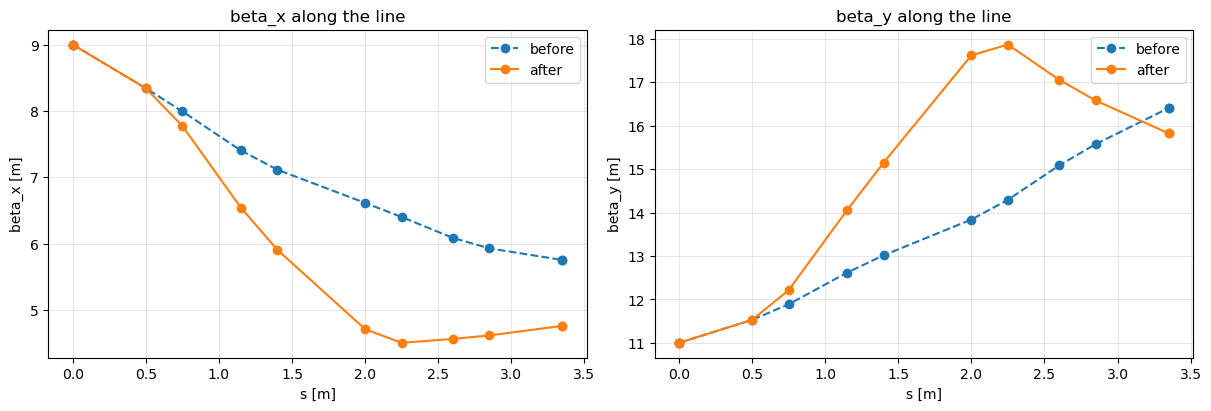

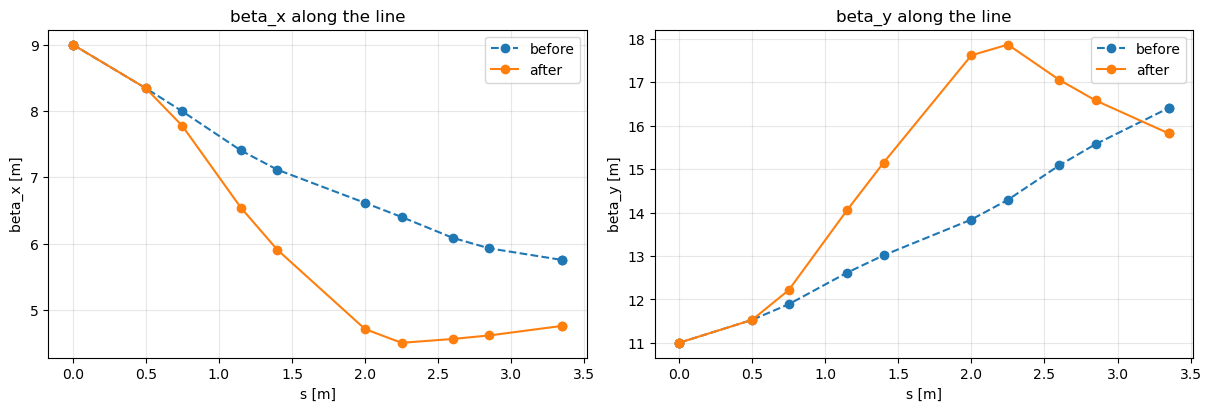

In [9]:
s_before, bx_before, by_before = beta_trace(states_before)
s_after, bx_after, by_after = beta_trace(states_after)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax[0].plot(s_before, bx_before, 'o--', label='before')
ax[0].plot(s_after, bx_after, 'o-', label='after')
ax[0].set_title('beta_x along the line')
ax[0].set_xlabel('s [m]')
ax[0].set_ylabel('beta_x [m]')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(s_before, by_before, 'o--', label='before')
ax[1].plot(s_after, by_after, 'o-', label='after')
ax[1].set_title('beta_y along the line')
ax[1].set_xlabel('s [m]')
ax[1].set_ylabel('beta_y [m]')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

fig


## Takeaways

- For element parameters and linear Twiss propagation, Ocelot already has enough infrastructure to write pure differentiable objectives.
- The linked-variable story is straightforward: just map one optimization variable to several element overrides.
- Energy-changing elements such as cavities already fit this pattern through `trace_linear_twiss(...)`.
- Some corners are still not autodiff-safe. The direct drift `R12` example shows one of them clearly.
- The multi-quadrupole example is the real reason to do this work: we can build nontrivial optics objectives directly from Ocelot physics and feed exact gradients into an optimizer.
